# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    RandomFlip,
    RandomRotation,
    RandomZoom
)

from tensorflow.keras.callbacks import EarlyStopping

🧹 Preprocessing
We normalize pixel values from 0–255 → 0–1 so training becomes stable.

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Test Images:", x_test.shape)

Training Images: (50000, 32, 32, 3)
Test Images: (10000, 32, 32, 3)


In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

🖼️ Visualize Sample Images

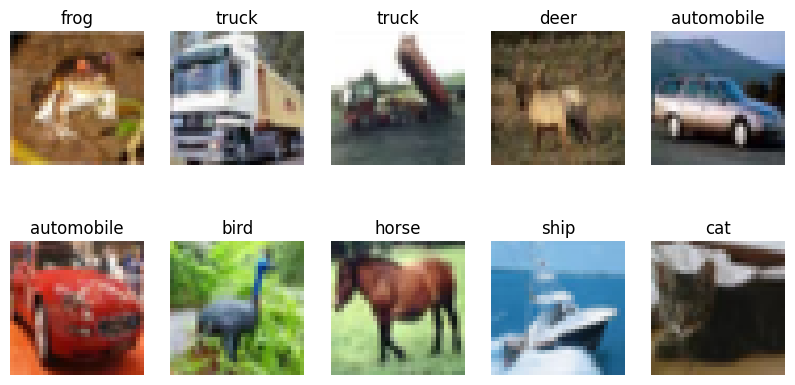

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
print(x_train.min(), x_train.max())

0.0 1.0


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.


In [ ]:
ann_model = Sequential([

    Flatten(input_shape=(32,32,3)),

    Dense(512, activation='relu'),
    Dropout(0.3),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Compile ANN

In [ ]:
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train ANN

In [ ]:
ann_history = ann_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.2469 - loss: 2.0447 - val_accuracy: 0.3174 - val_loss: 1.8979
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.2837 - loss: 1.9379 - val_accuracy: 0.3084 - val_loss: 1.8860
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.3046 - loss: 1.8884 - val_accuracy: 0.3484 - val_loss: 1.8378
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3159 - loss: 1.8559 - val_accuracy: 0.3567 - val_loss: 1.7862
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.3253 - loss: 1.8432 - val_accuracy: 0.3654 - val_loss: 1.7970
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.3347 - loss: 1.8168 - val_accuracy: 0.3760 - val_loss: 1.7674
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.3411 - loss: 1.8041 - val_accuracy: 0.3830 - val_loss: 1.7439
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.3452 - loss: 1.7940 - 

## ANN Evaluation

In [ ]:
ann_loss, ann_acc = ann_model.evaluate(
    x_test,
    y_test
)

print("ANN Accuracy:", ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3891 - loss: 1.7183
ANN Accuracy: 0.38909998536109924


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile CNN

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train CNN

In [ ]:
cnn_history = cnn_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 152ms/step - accuracy: 0.5210 - loss: 1.3602 - val_accuracy: 0.5404 - val_loss: 1.3210
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 150ms/step - accuracy: 0.6587 - loss: 0.9720 - val_accuracy: 0.6141 - val_loss: 1.1215
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 150ms/step - accuracy: 0.7180 - loss: 0.8062 - val_accuracy: 0.5722 - val_loss: 1.3290
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.7611 - loss: 0.6778 - val_accuracy: 0.6459 - val_loss: 1.0711
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 149ms/step - accuracy: 0.8002 - loss: 0.5683 - val_accuracy: 0.6678 - val_loss: 1.0838
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.8359 - loss: 0.4680 - val_accuracy: 0.6913 - val_loss: 1.0243
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.8699 - loss: 0.3710 - val_accuracy: 0.6299 - val_loss: 1.5163
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.8979 - loss

CNN Evaluation

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test,
    y_test
)

print("CNN Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6768 - loss: 1.4738
CNN Accuracy: 0.676800012588501


📈 Compare Learning Curves

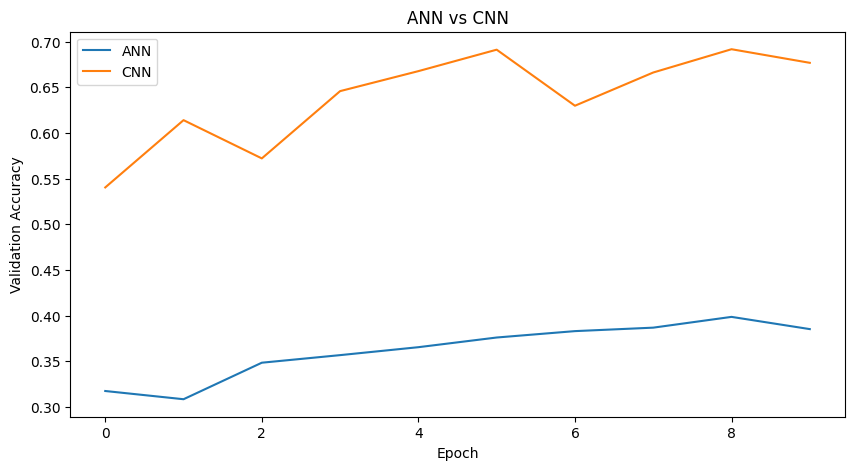

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN")

plt.legend()

plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation

This strategy improves generalization by generating transformed images.

In [ ]:
augmentation = Sequential([

    RandomFlip("horizontal"),

    RandomRotation(0.1),

    RandomZoom(0.1)

])

Augmented CNN


In [ ]:
augmented_cnn = Sequential([

    augmentation,

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

Train Augmented CNN

In [ ]:
augmented_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = augmented_cnn.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 119s 93ms/step - accuracy: 0.4533 - loss: 1.5363 - val_accuracy: 0.4272 - val_loss: 1.8276
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 93ms/step - accuracy: 0.5444 - loss: 1.2756 - val_accuracy: 0.5096 - val_loss: 1.4290
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 111s 89ms/step - accuracy: 0.5820 - loss: 1.1752 - val_accuracy: 0.6258 - val_loss: 1.0732
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 116s 93ms/step - accuracy: 0.6101 - loss: 1.1066 - val_accuracy: 0.6167 - val_loss: 1.1258
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 138s 90ms/step - accuracy: 0.6254 - loss: 1.0627 - val_accuracy: 0.6382 - val_loss: 1.0693
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 110s 88ms/step - accuracy: 0.6392 - loss: 1.0237 - val_accuracy: 0.5985 - val_loss: 1.2235
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 112s 90ms/step - accuracy: 0.6512 - loss: 0.9969 - val_accuracy: 0.6463 - val_loss: 1.0876
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 116s 92ms/step - accuracy: 

Evaluate

In [ ]:
aug_loss, aug_acc = augmented_cnn.evaluate(
    x_test,
    y_test
)

print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6744 - loss: 0.9515
Augmented CNN Accuracy: 0.6743999719619751



# Increase ANN Layers

In [ ]:
deep_ann = Sequential([

    Flatten(input_shape=(32,32,3)),

    Dense(1024, activation='relu'),
    Dropout(0.3),

    Dense(512, activation='relu'),
    Dropout(0.3),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [ ]:
# Compile
deep_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train
deep_ann_history = deep_ann.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 74ms/step - accuracy: 0.2245 - loss: 2.0755 - val_accuracy: 0.3137 - val_loss: 1.8901
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.2954 - loss: 1.9128 - val_accuracy: 0.3313 - val_loss: 1.8493
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.3098 - loss: 1.8744 - val_accuracy: 0.3310 - val_loss: 1.8440
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 74ms/step - accuracy: 0.3223 - loss: 1.8487 - val_accuracy: 0.3535 - val_loss: 1.8049
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 72ms/step - accuracy: 0.3316 - loss: 1.8251 - val_accuracy: 0.3599 - val_loss: 1.7917
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.3386 - loss: 1.8107 - val_accuracy: 0.3803 - val_loss: 1.7621
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.3506 - loss: 1.7882 - val_accuracy: 0.3597 - val_loss: 1.7697
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.3560 - loss: 1.7739 - 

In [ ]:
# Evaluate
deep_ann_loss, deep_ann_acc = deep_ann.evaluate(
    x_test,
    y_test
)

print("Deep ANN Accuracy:", deep_ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4097 - loss: 1.6893
Deep ANN Accuracy: 0.4097000062465668


In [ ]:
# Comparison
print("ANN Accuracy:", ann_acc)
print("Deep ANN Accuracy:", deep_ann_acc)

ANN Accuracy: 0.38909998536109924
Deep ANN Accuracy: 0.4097000062465668




CNN Filter Scaling

In [ ]:
cnn_128 = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(256, activation='relu'),

    Dense(10, activation='softmax')
])



# Increase Epochs to 20

In [ ]:
cnn_128.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
cnn20_history = cnn_128.fit(
    x_train,
    y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 138s 108ms/step - accuracy: 0.5472 - loss: 1.2879 - val_accuracy: 0.6034 - val_loss: 1.1126
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 112ms/step - accuracy: 0.6962 - loss: 0.8670 - val_accuracy: 0.6135 - val_loss: 1.0963
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 136s 109ms/step - accuracy: 0.7559 - loss: 0.7013 - val_accuracy: 0.6480 - val_loss: 1.0224
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 134s 108ms/step - accuracy: 0.8005 - loss: 0.5725 - val_accuracy: 0.7400 - val_loss: 0.7814
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 135s 108ms/step - accuracy: 0.8384 - loss: 0.4581 - val_accuracy: 0.7125 - val_loss: 0.9686
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 136s 109ms/step - accuracy: 0.8806 - loss: 0.3439 - val_accuracy: 0.7116 - val_loss: 1.0122
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 135s 108ms/step - accuracy: 0.9050 - loss: 0.2698 - val_accuracy: 0.7227 - val_loss: 1.0306
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 138s 111ms/step - ac



# EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
cnn_es_history = cnn_128.fit(
    x_train,
    y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 137s 110ms/step - accuracy: 0.9782 - loss: 0.0656 - val_accuracy: 0.7449 - val_loss: 1.6561
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 138s 107ms/step - accuracy: 0.9790 - loss: 0.0653 - val_accuracy: 0.7195 - val_loss: 1.9337
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 145s 110ms/step - accuracy: 0.9780 - loss: 0.0662 - val_accuracy: 0.7510 - val_loss: 1.5988
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 108ms/step - accuracy: 0.9811 - loss: 0.0561 - val_accuracy: 0.7187 - val_loss: 2.0911
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 143s 109ms/step - accuracy: 0.9828 - loss: 0.0535 - val_accuracy: 0.6982 - val_loss: 2.3265
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 134s 107ms/step - accuracy: 0.9817 - loss: 0.0566 - val_accuracy: 0.7511 - val_loss: 1.7556




Evaluate EarlyStopping Model

In [ ]:
cnn_es_loss, cnn_es_acc = cnn_128.evaluate(
    x_test,
    y_test
)

print(cnn_es_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7393 - loss: 1.6984
0.739300012588501


# 📊 Final Comparison Table

In [ ]:
results = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN"
    ],
    "Accuracy": [
        ann_acc,
        cnn_acc
    ]
})

results

,Model,Accuracy
0,ANN,0.3891
1,CNN,0.6768


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**